# 📊 Real A/B Test Evaluation 

## 🎯 Project Objective
The goal of this analysis is to evaluate whether the new webpage design leads to a statistically significant improvement in user conversion rates compared to the existing page. We use **real A/B test data** and apply a **z-test for proportions** to test our hypothesis.


### Importing Libraries 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Loading Data

In [28]:
df = pd.read_csv('D:/Projects GIT/Real-A-B-Test-Evaluation/ab_data.csv')
df.head()


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### Data Exploration & Cleaning

#### Basic Info

In [35]:
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.info()

Shape of dataset: (294478, 5)

Missing values:
 user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


#### Value Counts 

In [38]:
print("\nGroup distribution:\n", df['group'].value_counts())
print("\nLanding page distribution:\n", df['landing_page'].value_counts())
print("\nConversion distribution:\n", df['converted'].value_counts())


Group distribution:
 group
treatment    147276
control      147202
Name: count, dtype: int64

Landing page distribution:
 landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

Conversion distribution:
 converted
0    259241
1     35237
Name: count, dtype: int64


#### Checking Mismatches 

In [43]:
mismatch = df.query("(group == 'treatment' and landing_page != 'new_page') or (group == 'control' and landing_page != 'old_page')")
print(f"\nMismatched rows: {mismatch.shape[0]}")

#Drop mismatches
df_clean = df.drop(mismatch.index)


Mismatched rows: 3893


#### Checking for Duplicates

In [45]:
duplicate_users = df_clean[df_clean.duplicated('user_id')]
print(f"\nDuplicate user_id entries: {duplicate_users.shape[0]}")

# 8. Drop duplicate user_ids
df_clean = df_clean.drop_duplicates('user_id')

# Final check
print("\nCleaned Data Shape:", df_clean.shape)


Duplicate user_id entries: 1

Cleaned Data Shape: (290584, 5)


### EDA & Visuals

#### Conversion Rate

In [49]:
#Overall conversion rate
overall_conv = df_clean['converted'].mean()
print(f"Overall conversion rate: {overall_conv:.4f}")

#Conversion rate by group
group_conv = df_clean.groupby('group')['converted'].mean()
print("\nConversion rate by group:\n", group_conv)

Overall conversion rate: 0.1196

Conversion rate by group:
 group
control      0.120386
treatment    0.118808
Name: converted, dtype: float64


##### Bar plot of conversion rate by group

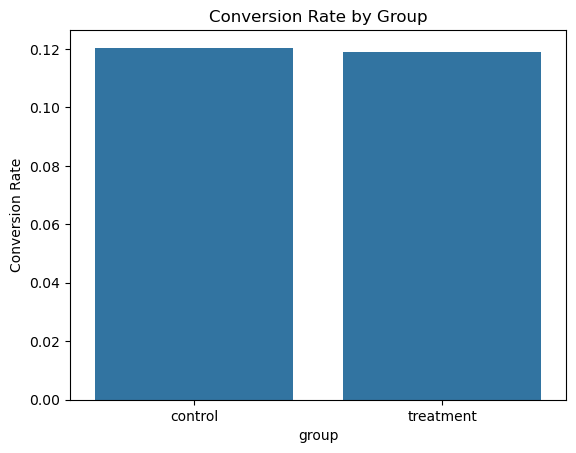

In [52]:
sns.barplot(x=group_conv.index, y=group_conv.values)
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

##### Countplot of group sizes

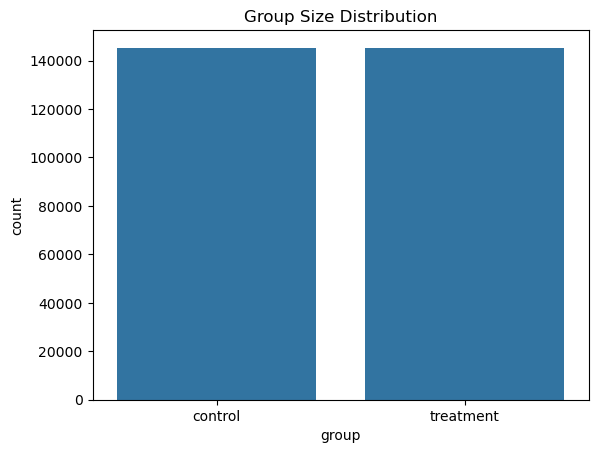

In [54]:
sns.countplot(data=df_clean, x='group')
plt.title("Group Size Distribution")
plt.show()

### Setting up Hypotheses

In [15]:
# Split into treatment & control
control_group = df_clean[df_clean['group'] == 'control']['converted']
treatment_group = df_clean[df_clean['group'] == 'treatment']['converted']

# Mean conversions
print(f"Control Conversion Rate: {control_group.mean():.4f}")
print(f"Treatment Conversion Rate: {treatment_group.mean():.4f}")

# Perform a two-proportion z-test
import statsmodels.api as sm

convert_counts = np.array([treatment_group.sum(), control_group.sum()])
n_obs = np.array([treatment_group.count(), control_group.count()])

z_stat, p_val = sm.stats.proportions_ztest(convert_counts, n_obs, alternative='larger')

print(f"\nZ-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

# Decision
alpha = 0.05
if p_val < alpha:
    print("✅ Reject H₀: The new page performs significantly better.")
else:
    print("❌ Fail to Reject H₀: No evidence the new page performs better.")


Control Conversion Rate: 0.1204
Treatment Conversion Rate: 0.1188

Z-Statistic: -1.3109
P-Value: 0.9051
❌ Fail to Reject H₀: No evidence the new page performs better.


In [19]:
with open('D:/Projects GIT/Real-A-B-Test-Evaluation/results/ab_test_summary.txt', 'w', encoding='utf-8') as f:
    f.write("Real A/B Test Evaluation Results\n")
    f.write("="*40 + "\n")
    f.write(f"Control Conversion Rate: {control_group.mean():.4f}\n")
    f.write(f"Treatment Conversion Rate: {treatment_group.mean():.4f}\n")
    f.write(f"Z-Statistic: {z_stat:.4f}\n")
    f.write(f"P-Value: {p_val:.4f}\n")
    f.write("Conclusion: " + 
            ("Reject H0 - New page is better\n" if p_val < alpha else "Fail to Reject H0 - No significant improvement\n"))
